In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

In [3]:
dataFrame = pd.read_excel("merc.xlsx")

In [ ]:
dataFrame.head() #tax(vergi)  mpg(mile per galon) 

,year,price,transmission,mileage,tax,mpg,engineSize
0,2005,5200,Automatic,63000,325,32.1,1.8
1,2017,34948,Automatic,27000,20,61.4,2.1
2,2016,49948,Automatic,6200,555,28.0,5.5
3,2016,61948,Automatic,16000,325,30.4,4.0
4,2016,73948,Automatic,4000,325,30.1,4.0


In [6]:
dataFrame.shape

(13119, 7)

In [8]:
dataFrame.describe()

,year,price,mileage,tax,mpg,engineSize
count,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000
mean,2017.296288,24698.596920,21949.559037,129.972178,55.155843,2.071530
std,2.224709,11842.675542,21176.512267,65.260286,15.220082,0.572426
min,1970.000000,650.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,17450.000000,6097.500000,125.000000,45.600000,1.800000
50%,2018.000000,22480.000000,15189.000000,145.000000,56.500000,2.000000
75%,2019.000000,28980.000000,31779.500000,145.000000,64.200000,2.100000
max,2020.000000,159999.000000,259000.000000,580.000000,217.300000,6.200000


In [ ]:
dataFrame.isnull().sum() #her sutundaki boş değerleri (Nan) toplar

year            0
price           0
transmission    0
mileage         0
tax             0
mpg             0
engineSize      0
dtype: int64

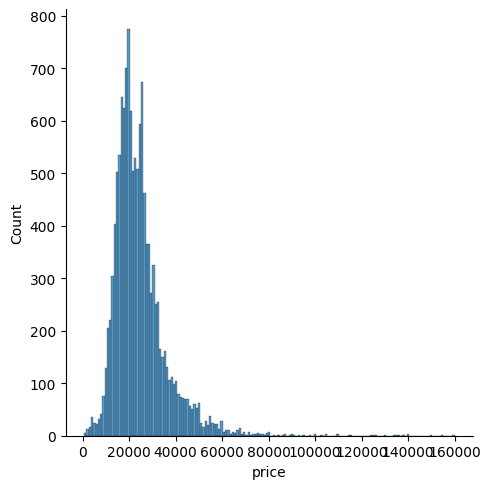

In [19]:
sbn.displot(dataFrame["price"])

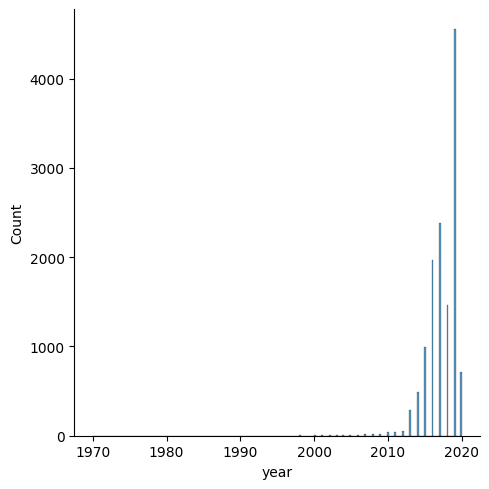

In [22]:
sbn.displot(dataFrame["year"])

In [31]:
dataFrame.corr(numeric_only=True) #korelasyon (iki değişkenin birbiriyle ilişkisini gosterir) +1 çok güçlü pozitif ilişki(biri artarken diğeri de artar) -1 tamamen ters yönlü ilişki (biri azalırken diğeri de azalır)

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.520712,-0.738027,0.012480,-0.094626,-0.142147
price,0.520712,1.000000,-0.537214,0.268717,-0.438445,0.516126
mileage,-0.738027,-0.537214,1.000000,-0.160223,0.202850,0.063652
tax,0.012480,0.268717,-0.160223,1.000000,-0.513742,0.338341
mpg,-0.094626,-0.438445,0.202850,-0.513742,1.000000,-0.339862
engineSize,-0.142147,0.516126,0.063652,0.338341,-0.339862,1.000000


In [33]:
dataFrame.corr(numeric_only=True)["price"].sort_values()

mileage      -0.537214
mpg          -0.438445
tax           0.268717
engineSize    0.516126
year          0.520712
price         1.000000
Name: price, dtype: float64

<Axes: xlabel='mileage', ylabel='price'>

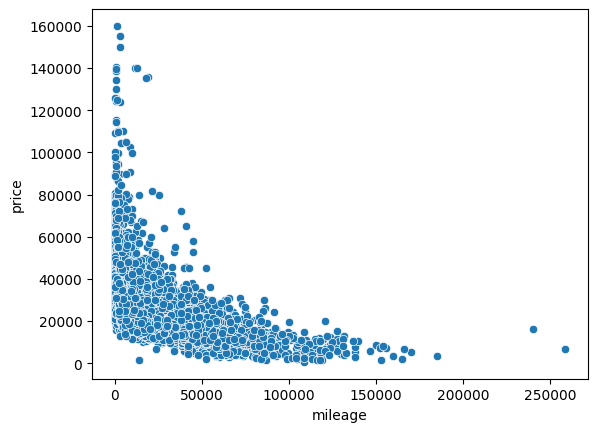

In [ ]:
sbn.scatterplot(x="mileage",y="price",data=dataFrame) #mil ve fiyat grafigi mil arttıkca fiyat azalıyor

In [ ]:
dataFrame.sort_values("price",ascending=False).head(20) #en yuksek fiyatlı 20 araba (ascending=artan sırada yukselen)

,year,price,transmission,mileage,tax,mpg,engineSize
6199,2020,159999,Semi-Auto,1350,145,21.4,4.0
10044,2020,154998,Automatic,3000,150,21.4,4.0
5,2011,149948,Automatic,3000,570,21.4,6.2
8737,2019,140319,Semi-Auto,785,150,22.1,4.0
6386,2018,139995,Semi-Auto,13046,145,21.4,4.0
8,2019,139948,Automatic,12000,145,21.4,4.0
9133,2019,139559,Semi-Auto,1000,145,22.1,4.0
8821,2020,138439,Semi-Auto,1000,145,22.1,4.0
5902,2018,135771,Semi-Auto,19000,145,21.4,4.0
7864,2018,135124,Semi-Auto,18234,150,21.4,4.0


In [36]:
dataFrame.sort_values("price",ascending=True).head(20) #en dusuk fiyatlı 20 araba

,year,price,transmission,mileage,tax,mpg,engineSize
11816,2003,650,Manual,109090,235,40.0,1.4
12008,2010,1350,Manual,116126,145,54.3,2.0
11765,2000,1490,Automatic,87000,265,27.2,3.2
11549,2002,1495,Automatic,13800,305,39.8,2.7
12594,2004,1495,Manual,119000,300,34.5,1.8
11174,2001,1695,Automatic,108800,325,31.7,3.2
12710,2006,1695,Automatic,153000,300,33.6,1.8
12766,2004,1780,Automatic,118000,265,41.5,2.2
12009,2007,1800,Automatic,84000,200,42.8,1.5
11764,1998,1990,Automatic,99300,265,32.1,2.3


## veri temizliği

data frame'in en yuksek fiyatlı %1'lik kısmını atacağım bu da 131 tane arabayı çıkartmak demek

veri seti icerisinde cok yuksek fiyatlı arabalar vardı bunları çıkartmaya karar verdik

In [38]:
yuzdeDoksanDokuzDataFrame = dataFrame.sort_values("price",ascending=False).iloc[131:] #en yüksek fiyata gore sıraladıktan sonra başlangıc olarak 131 ve bitiş olarak 131'den sonrası alınır yani en yuksek fiyatlı 131 araba haric diger degerleri alırız.

In [40]:
dataFrame.describe()

,year,price,mileage,tax,mpg,engineSize
count,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000,13119.000000
mean,2017.296288,24698.596920,21949.559037,129.972178,55.155843,2.071530
std,2.224709,11842.675542,21176.512267,65.260286,15.220082,0.572426
min,1970.000000,650.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,17450.000000,6097.500000,125.000000,45.600000,1.800000
50%,2018.000000,22480.000000,15189.000000,145.000000,56.500000,2.000000
75%,2019.000000,28980.000000,31779.500000,145.000000,64.200000,2.100000
max,2020.000000,159999.000000,259000.000000,580.000000,217.300000,6.200000


In [39]:
yuzdeDoksanDokuzDataFrame.describe()

,year,price,mileage,tax,mpg,engineSize
count,12988.000000,12988.000000,12988.000000,12988.000000,12988.000000,12988.000000
mean,2017.281876,24074.926933,22132.741146,129.689714,55.437142,2.050901
std,2.228515,9866.224575,21196.776401,65.183076,15.025999,0.532596
min,1970.000000,650.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,17357.500000,6322.000000,125.000000,45.600000,1.675000
50%,2018.000000,22299.000000,15369.500000,145.000000,56.500000,2.000000
75%,2019.000000,28706.000000,31982.250000,145.000000,64.200000,2.100000
max,2020.000000,65990.000000,259000.000000,580.000000,217.300000,6.200000


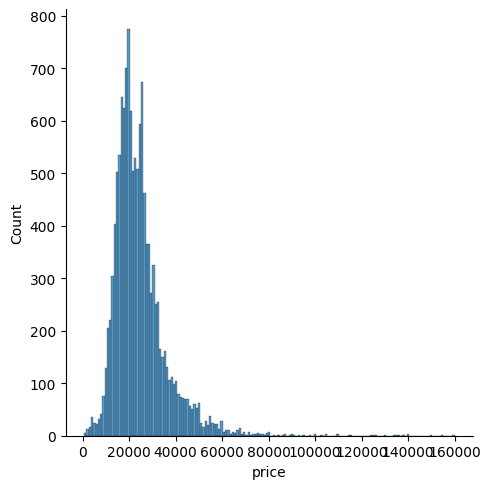

In [44]:
sbn.displot(dataFrame["price"])

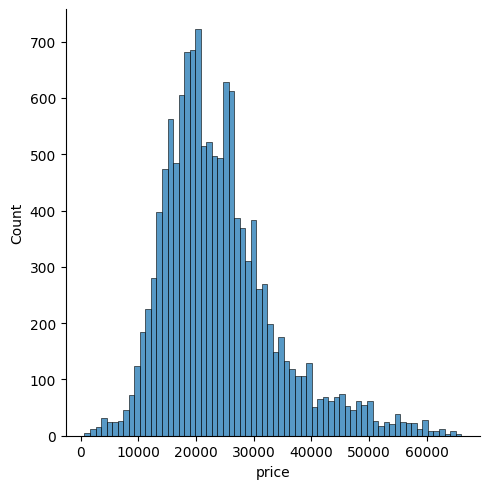

In [ ]:
sbn.displot(yuzdeDoksanDokuzDataFrame["price"]) #daha normal bir dağılım oldu

In [ ]:
dataFrame.groupby("year").mean(numeric_only=True)["price"] #yıllara gore gruplayıp o yıla gore ortalamasını alır

year
1970    24999.000000
1997     9995.000000
1998     8605.000000
1999     5995.000000
2000     5743.333333
2001     4957.900000
2002     5820.444444
2003     4878.000000
2004     4727.615385
2005     4426.111111
2006     4036.875000
2007     5136.045455
2008     6967.437500
2009     6166.764706
2010     8308.473684
2011    12624.894737
2012    10845.140351
2013    11939.842466
2014    14042.936864
2015    16731.780020
2016    19307.892948
2017    21514.307854
2018    25720.162918
2019    31290.020865
2020    35433.282337
Name: price, dtype: float64

In [47]:
yuzdeDoksanDokuzDataFrame.groupby("year").mean(numeric_only=True)["price"]

year
1970    24999.000000
1997     9995.000000
1998     8605.000000
1999     5995.000000
2000     5743.333333
2001     4957.900000
2002     5820.444444
2003     4878.000000
2004     4727.615385
2005     4426.111111
2006     4036.875000
2007     5136.045455
2008     6967.437500
2009     6166.764706
2010     8308.473684
2011     8913.459459
2012    10845.140351
2013    11939.842466
2014    14042.936864
2015    16647.822222
2016    19223.558943
2017    21356.280421
2018    24800.844506
2019    30289.524832
2020    34234.794872
Name: price, dtype: float64

1970 yılının fiyatlarının ortalamasında bir gariplik oldugu icin bunu çıkartmak istiyorum

In [48]:
dataFrame[dataFrame.year != 1970].groupby("year").mean(numeric_only=True)["price"]

year
1997     9995.000000
1998     8605.000000
1999     5995.000000
2000     5743.333333
2001     4957.900000
2002     5820.444444
2003     4878.000000
2004     4727.615385
2005     4426.111111
2006     4036.875000
2007     5136.045455
2008     6967.437500
2009     6166.764706
2010     8308.473684
2011    12624.894737
2012    10845.140351
2013    11939.842466
2014    14042.936864
2015    16731.780020
2016    19307.892948
2017    21514.307854
2018    25720.162918
2019    31290.020865
2020    35433.282337
Name: price, dtype: float64

In [51]:
dataFrame = yuzdeDoksanDokuzDataFrame

In [52]:
dataFrame.describe()

,year,price,mileage,tax,mpg,engineSize
count,12988.000000,12988.000000,12988.000000,12988.000000,12988.000000,12988.000000
mean,2017.281876,24074.926933,22132.741146,129.689714,55.437142,2.050901
std,2.228515,9866.224575,21196.776401,65.183076,15.025999,0.532596
min,1970.000000,650.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,17357.500000,6322.000000,125.000000,45.600000,1.675000
50%,2018.000000,22299.000000,15369.500000,145.000000,56.500000,2.000000
75%,2019.000000,28706.000000,31982.250000,145.000000,64.200000,2.100000
max,2020.000000,65990.000000,259000.000000,580.000000,217.300000,6.200000


In [53]:
dataFrame = dataFrame[dataFrame.year != 1970]

In [55]:
dataFrame.groupby("year").mean(numeric_only=True)["price"]

year
1997     9995.000000
1998     8605.000000
1999     5995.000000
2000     5743.333333
2001     4957.900000
2002     5820.444444
2003     4878.000000
2004     4727.615385
2005     4426.111111
2006     4036.875000
2007     5136.045455
2008     6967.437500
2009     6166.764706
2010     8308.473684
2011     8913.459459
2012    10845.140351
2013    11939.842466
2014    14042.936864
2015    16647.822222
2016    19223.558943
2017    21356.280421
2018    24800.844506
2019    30289.524832
2020    34234.794872
Name: price, dtype: float64

In [58]:
dataFrame = dataFrame.drop("transmission",axis=1) #transmission sutunu string oldugu icin onu cıkartıyoruz

KeyError: "['transmission'] not found in axis"

In [59]:
dataFrame.head()

,year,price,mileage,tax,mpg,engineSize
6177,2019,65990,5076,150,30.4,3.0
5779,2020,65990,999,145,28.0,4.0
3191,2020,65980,3999,145,28.0,4.0
4727,2019,65000,3398,145,27.2,4.0
8814,2019,64999,119,145,40.9,3.0


## model oluşturma

In [61]:
y = dataFrame["price"].values #y degeri ucretler
x = dataFrame.drop("price",axis=1).values #x degerlerim dataFrame icindeki ucret sutunu haric digerleri


In [67]:
dataFrame.head()

,year,price,mileage,tax,mpg,engineSize
6177,2019,65990,5076,150,30.4,3.0
5779,2020,65990,999,145,28.0,4.0
3191,2020,65980,3999,145,28.0,4.0
4727,2019,65000,3398,145,27.2,4.0
8814,2019,64999,119,145,40.9,3.0


In [62]:
x

array([[2.01900e+03, 5.07600e+03, 1.50000e+02, 3.04000e+01, 3.00000e+00],
       [2.02000e+03, 9.99000e+02, 1.45000e+02, 2.80000e+01, 4.00000e+00],
       [2.02000e+03, 3.99900e+03, 1.45000e+02, 2.80000e+01, 4.00000e+00],
       ...,
       [2.00000e+03, 8.70000e+04, 2.65000e+02, 2.72000e+01, 3.20000e+00],
       [2.01000e+03, 1.16126e+05, 1.45000e+02, 5.43000e+01, 2.00000e+00],
       [2.00300e+03, 1.09090e+05, 2.35000e+02, 4.00000e+01, 1.40000e+00]],
      shape=(12987, 5))

In [63]:
y

array([65990, 65990, 65980, ...,  1490,  1350,   650], shape=(12987,))

In [68]:
from sklearn.model_selection import train_test_split

In [70]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=10)

In [71]:
len(x_train)

9090

In [72]:
len(x_test)

3897

In [73]:
len(y_train)

9090

In [74]:
len(y_test)

3897

In [75]:
from sklearn.preprocessing import MinMaxScaler

In [76]:
scaler = MinMaxScaler()

In [77]:
x_train = scaler.fit_transform(x_train)

In [78]:
x_test = scaler.transform(x_test)

In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [81]:
model = Sequential()

model.add(Dense(12,activation="relu"))
model.add(Dense(12,activation="relu"))
model.add(Dense(12,activation="relu"))
model.add(Dense(12,activation="relu"))

model.add(Dense(1))

model.compile(optimizer="adam",loss="mse")

In [82]:
model.fit(x=x_train,y=y_train,validation_data=(x_test,y_test),batch_size=250,epochs=300) #validation = model ogrenirken kendini kontrol eder

Epoch 1/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 672149440.0000 - val_loss: 688107904.0000
Epoch 2/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 672132480.0000 - val_loss: 688081344.0000
Epoch 3/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 672083840.0000 - val_loss: 687995136.0000
Epoch 4/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 671918912.0000 - val_loss: 687689664.0000
Epoch 5/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 671354176.0000 - val_loss: 686703744.0000
Epoch 6/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 669706112.0000 - val_loss: 684043584.0000
Epoch 7/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 665592768.0000 - val_loss: 677821824.0000
Epoch 8/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 656795392.0000 - val_loss: 665398656.0000
Epoch 9/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 640317440.0000 - val_loss: 643285248.0000
Epoch 10/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 612474432.0000 - val_loss: 6075

val_loss : validation degerleri uzerindeki hata degerleri

In [83]:
kayipVerisi = pd.DataFrame(model.history.history)

In [84]:
kayipVerisi.head()

,loss,val_loss
0,672149440.0,688107904.0
1,672132480.0,688081344.0
2,672083840.0,687995136.0
3,671918912.0,687689664.0
4,671354176.0,686703744.0


<Axes: >

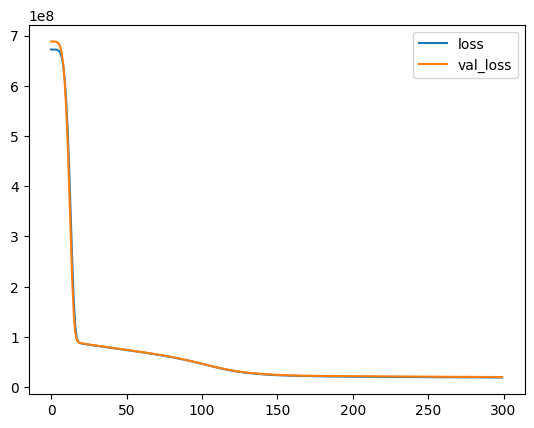

In [85]:
kayipVerisi.plot()

In [89]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [87]:
tahminDizisi = model.predict(x_test)

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step


In [88]:
tahminDizisi

array([[26537.305],
       [23894.133],
       [24957.414],
       ...,
       [23092.84 ],
       [19937.336],
       [26218.383]], shape=(3897, 1), dtype=float32)

In [ ]:
mean_absolute_error(y_test,tahminDizisi) #price degerinde 3196 birimlik bir sapma ile dogru tahmin yapıyoruz 

3196.941162109375

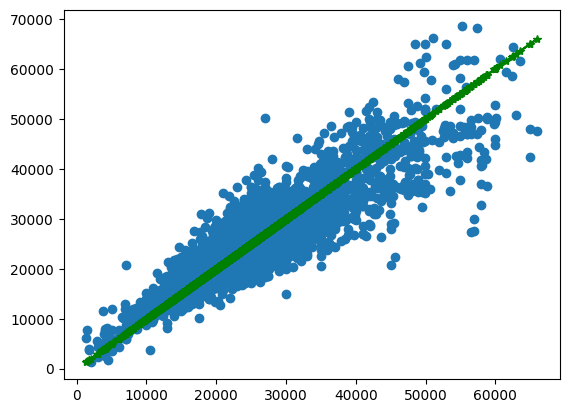

In [93]:
plt.scatter(y_test,tahminDizisi)
plt.plot(y_test,y_test,"g-*")

In [94]:
dataFrame.iloc[2]

year           2020.0
price         65980.0
mileage        3999.0
tax             145.0
mpg              28.0
engineSize        4.0
Name: 3191, dtype: float64

In [96]:
yeniArabaSeries = dataFrame.drop("price",axis=1).iloc[2]

In [97]:
yeniArabaSeries = scaler.transform(yeniArabaSeries.values.reshape(-1,5))

In [98]:
model.predict(yeniArabaSeries)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([[62720.785]], dtype=float32)